In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("../data/cleaned_churn.csv")

In [3]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,29,29,0,0,0,0,1,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,56,1889,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,0,1,1,0,...,53,108,1,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,1,0,1,...,42,1840,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70,151,1,0,0,0,1,0,1,0


In [4]:
df['AvgSpend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [5]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,AvgSpend
0,0,0,1,0,1,0,0,0,1,0,...,29,0,0,0,0,1,0,0,0,14.500000
1,1,0,0,0,34,1,0,1,0,1,...,1889,0,1,0,0,0,1,0,0,53.971429
2,1,0,0,0,2,1,0,1,1,0,...,108,1,0,0,0,0,1,0,0,36.000000
3,1,0,0,0,45,0,0,1,0,1,...,1840,0,1,0,0,0,0,0,0,40.000000
4,0,0,0,0,2,1,0,0,0,0,...,151,1,0,0,0,1,0,1,0,50.333333


In [6]:
df['TenureGroup'] = pd.cut(df['tenure'],
                          bins=[0,12,24,48,72],
                          labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

In [7]:
df = pd.get_dummies(df, columns=['TenureGroup'], drop_first=True)

In [8]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,AvgSpend,TenureGroup_1-2yr,TenureGroup_2-4yr,TenureGroup_4-6yr
0,0,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,14.500000,False,False,False
1,1,0,0,0,34,1,0,1,0,1,...,0,0,0,1,0,0,53.971429,False,True,False
2,1,0,0,0,2,1,0,1,1,0,...,0,0,0,1,0,0,36.000000,False,False,False
3,1,0,0,0,45,0,0,1,0,1,...,0,0,0,0,0,0,40.000000,False,True,False
4,0,0,0,0,2,1,0,0,0,0,...,0,0,1,0,1,0,50.333333,False,False,False


In [9]:
df = df.astype(int)

<Axes: >

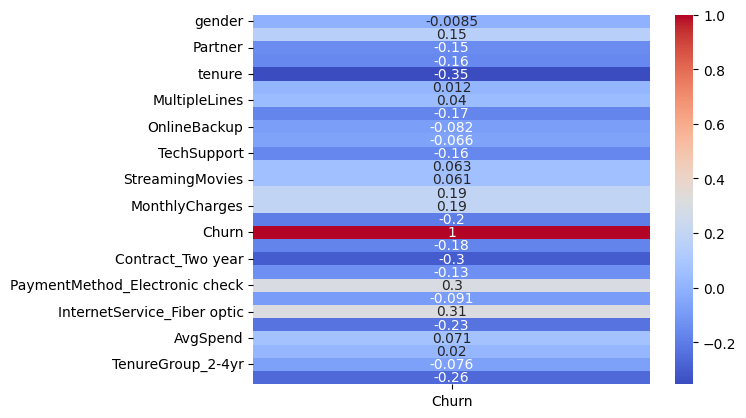

In [10]:
sns.heatmap(df.select_dtypes(include='number').corr()[['Churn']], annot=True, cmap='coolwarm')

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [16]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [17]:
print(importance.head(10))

                           Feature  Importance
21     InternetService_Fiber optic    0.472738
17               Contract_Two year    0.156293
22              InternetService_No    0.092806
16               Contract_One year    0.065906
12                 StreamingMovies    0.019388
4                           tenure    0.019156
7                   OnlineSecurity    0.012022
5                     PhoneService    0.011757
6                    MultipleLines    0.011077
19  PaymentMethod_Electronic check    0.010654


In [18]:
import shap

c:\Users\rohan\OneDrive\Desktop\Telco Customer Churn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


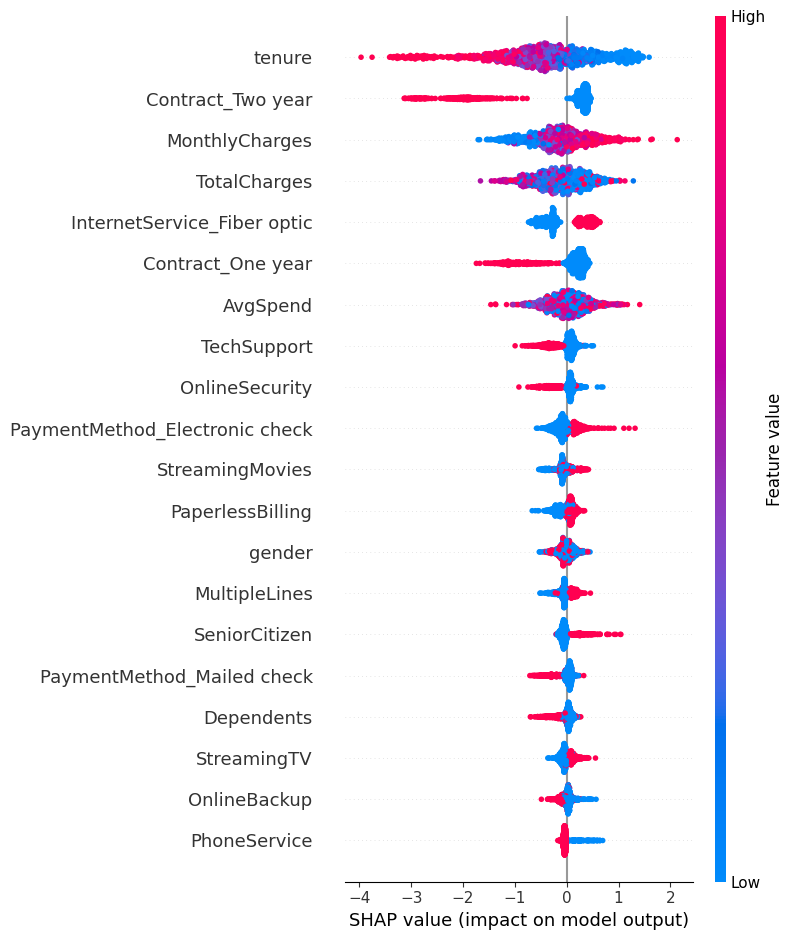

In [19]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)